# Citation Hallucination Detection Framework (Corrected V5)

This notebook provides a corrected, reproducible implementation of a citation hallucination detection framework.

## What is fixed in this version
- Proper **train / validation / test** evaluation protocol
- Threshold optimized on **validation only** and reported on **test only**
- Correct distinction between **DOI pattern presence** and **DOI validity**
- Improved **title extraction** for metadata matching
- Optional **semantic similarity** using `sentence-transformers`
- Correct **near-miss labeling**
- Cleaner **ablation study**
- Support for **Google Drive output saving** (tables, figures, cached results)

## Outputs saved to Google Drive
This notebook saves:
- metrics as CSV/JSON
- confusion matrix
- ROC curve
- Precision–Recall curve
- ablation results
- false positive / false negative samples
- real-LLM evaluation results

You can run it directly in **Google Colab**.


## 1. Environment setup


In [4]:
!pip -q install requests pandas numpy scikit-learn tqdm seaborn matplotlib rapidfuzz

USE_SEMANTIC_SIMILARITY = True
if USE_SEMANTIC_SIMILARITY:
    !pip -q install sentence-transformers

print('Environment ready.')


Environment ready.


## 2. Mount Google Drive and create output folders


In [5]:
from pathlib import Path
from datetime import datetime

RUN_TAG = datetime.now().strftime('%Y%m%d_%H%M%S')

ROOT = Path('/kaggle/working/Citation_Hallucination_Outputs')

RUN_DIR = ROOT / f'run_{RUN_TAG}'
FIG_DIR = RUN_DIR / 'figures'
TABLE_DIR = RUN_DIR / 'tables'
CACHE_DIR = RUN_DIR / 'cache'

for p in [RUN_DIR, FIG_DIR, TABLE_DIR, CACHE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Outputs will be saved to:', RUN_DIR)


Outputs will be saved to: /kaggle/working/Citation_Hallucination_Outputs/run_20260311_035304


## 3. Imports and reproducibility


In [6]:
import re
import os
import json
import time
import random
import requests
import numpy as np
import pandas as pd

from tqdm import tqdm
from rapidfuzz import fuzz

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)

import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Random seed fixed at', RANDOM_SEED)


Random seed fixed at 42


## 4. Optional semantic similarity model


In [7]:
semantic_model = None
if USE_SEMANTIC_SIMILARITY:
    try:
        from sentence_transformers import SentenceTransformer
        from sklearn.metrics.pairwise import cosine_similarity
        semantic_model = SentenceTransformer('all-MiniLM-L6-v2')
        print('Semantic model loaded.')
    except Exception as e:
        print('Semantic model could not be loaded. Falling back to lexical similarity only.')
        print('Reason:', e)
        semantic_model = None

def semantic_similarity(title1, title2):
    if semantic_model is None:
        return 0.0
    if not title1 or not title2:
        return 0.0
    emb = semantic_model.encode([title1, title2])
    return float(cosine_similarity([emb[0]], [emb[1]])[0][0])


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Semantic model loaded.


## 5. Citation parsing helpers


In [8]:
DOI_PATTERN = r"\b10\.\d{4,9}/[-._;()/:A-Z0-9]+\b"
URL_PATTERN = r"https?://[^\s]+"

def extract_dois(text):
    return re.findall(DOI_PATTERN, text or '', re.IGNORECASE)

def extract_urls(text):
    return re.findall(URL_PATTERN, text or '')

def extract_candidate_title(text):
    if text is None:
        return ''
    t = str(text)
    t = re.split(r'\bDOI\s*:\s*', t, flags=re.IGNORECASE)[0]
    t = re.split(r'https?://', t)[0]
    t = re.sub(r'\(\d{4}\)', ' ', t)
    t = re.sub(r'\b\d{4}\b', ' ', t)
    t = re.sub(r'\bet al\.?', ' ', t, flags=re.IGNORECASE)
    t = re.sub(r'\s+', ' ', t)
    return t.strip(' .,:;-_')


## 6. CrossRef validation and caching


In [9]:
doi_cache = {}
metadata_cache = {}

def save_cache_files():
    (CACHE_DIR / 'doi_cache.json').write_text(json.dumps(doi_cache, indent=2))
    (CACHE_DIR / 'metadata_cache.json').write_text(json.dumps(metadata_cache, indent=2))

def validate_doi(doi):
    doi = str(doi).strip()
    if doi in doi_cache:
        return doi_cache[doi]
    try:
        url = f'https://api.crossref.org/works/{doi}'
        response = requests.get(url, timeout=8)
        result = response.status_code == 200
        doi_cache[doi] = result
        time.sleep(0.05)
        return result
    except Exception:
        doi_cache[doi] = False
        return False

def validate_url(url):
    try:
        r = requests.head(url, timeout=8, allow_redirects=True)
        if r.status_code == 200:
            return True
        r = requests.get(url, timeout=8, allow_redirects=True, stream=True)
        return r.status_code == 200
    except Exception:
        return False

def get_crossref_metadata(doi):
    doi = str(doi).strip()
    if doi in metadata_cache:
        return metadata_cache[doi]
    try:
        url = f'https://api.crossref.org/works/{doi}'
        response = requests.get(url, timeout=8)
        if response.status_code == 200:
            data = response.json()['message']
            title = data.get('title', [''])
            title = title[0] if title else ''
            out = {
                'title': title,
                'container-title': (data.get('container-title', ['']) or [''])[0],
                'publisher': data.get('publisher', ''),
                'DOI': data.get('DOI', doi)
            }
            metadata_cache[doi] = out
            time.sleep(0.05)
            return out
    except Exception:
        pass
    metadata_cache[doi] = None
    return None


## 7. Similarity functions


In [10]:
def lexical_title_similarity(title1, title2):
    if not title1 or not title2:
        return 0.0
    return fuzz.token_set_ratio(title1, title2) / 100.0

def metadata_similarity_check(text):
    dois = extract_dois(text)
    if not dois:
        return 0.0
    doi = dois[0]
    metadata = get_crossref_metadata(doi)
    if metadata is None:
        return 0.0
    crossref_title = metadata.get('title', '')
    citation_title = extract_candidate_title(text)
    lexical = lexical_title_similarity(citation_title, crossref_title)
    semantic = semantic_similarity(citation_title, crossref_title) if USE_SEMANTIC_SIMILARITY else 0.0
    return max(lexical, semantic)


## 8. Scoring function


In [11]:
def compute_suspicion_score(text):
    score = 0.0
    dois = extract_dois(text)
    urls = extract_urls(text)

    if dois:
        valid_any = any(validate_doi(d) for d in dois)
        if not valid_any:
            score += 0.50
        else:
            sim = metadata_similarity_check(text)
            if sim < 0.40:
                score += 0.20
    else:
        score += 0.30

    if urls:
        invalid_urls = sum(1 for u in urls if not validate_url(u))
        score += min(0.20 * invalid_urls, 0.30)

    title = extract_candidate_title(text)
    if len(title.split()) < 4:
        score += 0.10

    return min(score, 1.0)


## 9. Dataset construction


In [12]:
def generate_fake_citations(n=1000):
    fake = []
    for i in range(n):
        text = f'Fake Author {i} et al. 2022. Fabricated study on hallucination detection. DOI:10.9999/fake{i}'
        fake.append((text, 1, 'synthetic'))
    return fake

def fetch_real_citations(n=1000):
    citations = []
    url = 'https://api.crossref.org/works'
    params = {'rows': n}
    r = requests.get(url, params=params, timeout=20)
    items = r.json()['message']['items']
    for item in items:
        title = (item.get('title', ['']) or [''])[0]
        doi = item.get('DOI', '')
        year = item.get('issued', {}).get('date-parts', [[None]])[0][0]
        if not title or not doi:
            continue
        text = f'{title} DOI:{doi} ({year})'
        citations.append((text, 0, 'real'))
        if len(citations) >= n:
            break
    return citations

def generate_near_miss(real_citations, n=500):
    near = []
    valid_pool = [x for x in real_citations if 'DOI:' in x[0]]
    for _ in range(n):
        text, _, _ = random.choice(valid_pool)
        doi = text.split('DOI:')[1].split()[0].strip()
        if len(doi) > 1:
            last = doi[-1]
            replacement = str((int(last) + 1) % 10) if last.isdigit() else '9'
            modified = doi[:-1] + replacement
            if modified == doi:
                modified = doi + '9'
            new_text = text.replace(doi, modified)
            near.append((new_text, 1, 'near_miss'))
    return near

real_citations = fetch_real_citations(1000)
fake_citations = generate_fake_citations(1000)
near_miss = generate_near_miss(real_citations, 500)

dataset = real_citations + fake_citations + near_miss
df = pd.DataFrame(dataset, columns=['text', 'label', 'source_type'])

print('Dataset size:', len(df))
print(df['source_type'].value_counts())

df.to_csv(TABLE_DIR / 'dataset_full.csv', index=False)
df.head()


Dataset size: 2494
source_type
synthetic    1000
real          994
near_miss     500
Name: count, dtype: int64


,text,label,source_type
0,Soziale Innovation DOI:10.1007/978-3-658-17671...,0,real
1,Loot Crates DOI:10.1007/978-3-031-23161-2_3007...,0,real
2,"Sensor data analysis, reduction, and fusion fo...",0,real
3,The Fiscal Treatment of Family Size: A Further...,0,real
4,Teaching Comparative Education in Cuba and the...,0,real


## 10. Compute scores and engineered features


In [13]:
tqdm.pandas()

df['score'] = df['text'].progress_apply(compute_suspicion_score)

def has_doi_pattern(text):
    return int(len(extract_dois(text)) > 0)

def has_valid_doi(text):
    dois = extract_dois(text)
    if not dois:
        return 0
    return int(any(validate_doi(d) for d in dois))

def has_url(text):
    return int(len(extract_urls(text)) > 0)

def has_valid_url(text):
    urls = extract_urls(text)
    if not urls:
        return 0
    return int(any(validate_url(u) for u in urls))

df['has_doi_pattern'] = df['text'].apply(has_doi_pattern)
df['doi_valid'] = df['text'].apply(has_valid_doi)
df['has_url'] = df['text'].apply(has_url)
df['url_valid'] = df['text'].apply(has_valid_url)
df['title_similarity'] = df['text'].progress_apply(metadata_similarity_check)
df['near_miss_flag'] = (df['source_type'] == 'near_miss').astype(int)

df.to_csv(TABLE_DIR / 'dataset_with_scores.csv', index=False)
save_cache_files()
df.head()


100%|██████████| 2494/2494 [04:12<00:00,  9.86it/s]


,text,label,source_type,score,has_doi_pattern,doi_valid,has_url,url_valid,title_similarity,near_miss_flag
0,Soziale Innovation DOI:10.1007/978-3-658-17671...,0,real,0.1,1,1,0,0,1.0,0
1,Loot Crates DOI:10.1007/978-3-031-23161-2_3007...,0,real,0.1,1,1,0,0,1.0,0
2,"Sensor data analysis, reduction, and fusion fo...",0,real,0.0,1,1,0,0,1.0,0
3,The Fiscal Treatment of Family Size: A Further...,0,real,0.0,1,1,0,0,1.0,0
4,Teaching Comparative Education in Cuba and the...,0,real,0.0,1,1,0,0,1.0,0


## 11. Train / validation / test split


In [14]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=df['label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_df['label']
)

print('Train size:', len(train_df))
print('Validation size:', len(val_df))
print('Test size:', len(test_df))

train_df.to_csv(TABLE_DIR / 'train_split.csv', index=False)
val_df.to_csv(TABLE_DIR / 'validation_split.csv', index=False)
test_df.to_csv(TABLE_DIR / 'test_split.csv', index=False)


Train size: 1745
Validation size: 374
Test size: 375


## 12. Threshold optimization on validation set only


In [15]:
thresholds = np.arange(0.10, 1.00, 0.05)
best_threshold = 0.0
best_f1 = -1.0

val_y = val_df['label'].values
for t in thresholds:
    val_preds = (val_df['score'].values > t).astype(int)
    f1 = f1_score(val_y, val_preds)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = float(t)

print('Best threshold:', best_threshold)
print('Best validation F1:', best_f1)

(TABLE_DIR / 'threshold_selection.json').write_text(json.dumps({
    'best_threshold': best_threshold,
    'best_validation_f1': best_f1
}, indent=2))


Best threshold: 0.1
Best validation F1: 0.9386792452830188


71

## 13. Final evaluation on test set only


In [16]:
test_df = test_df.copy()
test_df['prediction'] = (test_df['score'] > best_threshold).astype(int)

y_true = test_df['label'].values
y_pred = test_df['prediction'].values
y_score = test_df['score'].values

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_true, y_score)
cm = confusion_matrix(y_true, y_pred)
TN, FP, FN, TP = cm.ravel()

summary = pd.DataFrame({
    'Metric': [
        'Total Test Samples', 'True Positives', 'True Negatives',
        'False Positives', 'False Negatives', 'Accuracy',
        'Precision', 'Recall', 'F1 Score', 'ROC-AUC'
    ],
    'Value': [
        len(test_df), TP, TN, FP, FN, accuracy,
        precision, recall, f1, roc_auc
    ]
})

display(summary)
summary.to_csv(TABLE_DIR / 'final_test_metrics.csv', index=False)
(TABLE_DIR / 'final_test_metrics.json').write_text(summary.to_json(orient='records', indent=2))


,Metric,Value
0,Total Test Samples,375.000000
1,True Positives,186.000000
2,True Negatives,150.000000
3,False Positives,0.000000
4,False Negatives,39.000000
5,Accuracy,0.896000
6,Precision,1.000000
7,Recall,0.826667
8,F1 Score,0.905109
9,ROC-AUC,0.908400


566

## 14. Confusion matrix, ROC curve, and PR curve


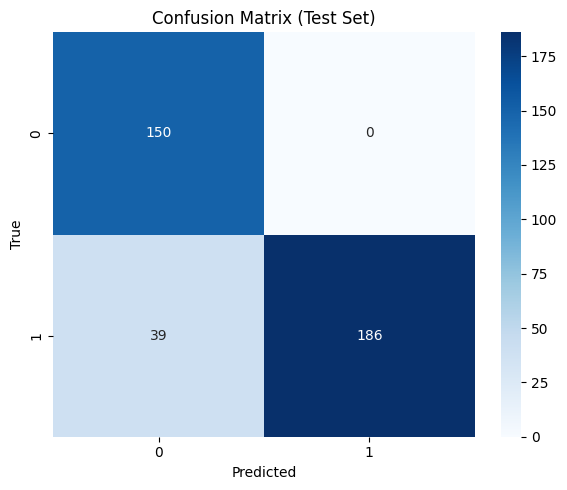

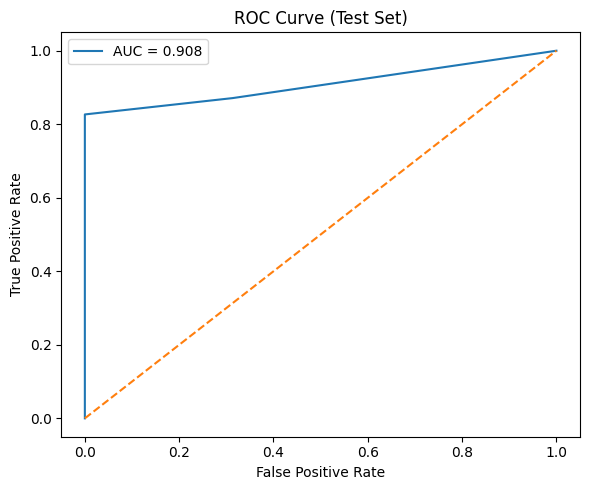

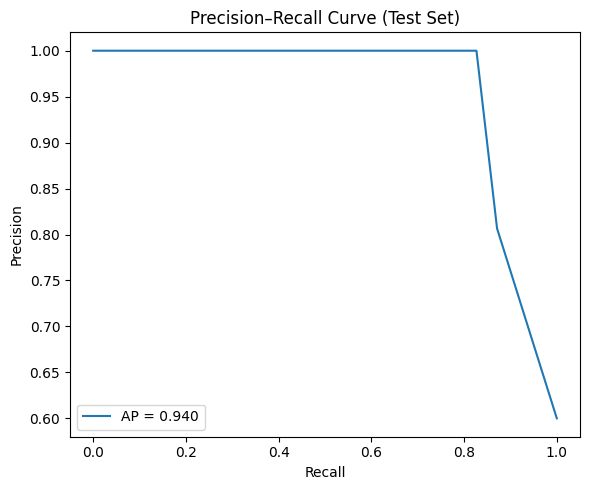

78

In [17]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_matrix_test.png', dpi=300, bbox_inches='tight')
plt.show()

fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
roc_auc_value = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_value:.3f}')
plt.plot([0,1], [0,1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'roc_curve_test.png', dpi=300, bbox_inches='tight')
plt.show()

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_true, y_score)
ap_score = average_precision_score(y_true, y_score)
plt.figure(figsize=(6,5))
plt.plot(recall_curve, precision_curve, label=f'AP = {ap_score:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve (Test Set)')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'precision_recall_curve_test.png', dpi=300, bbox_inches='tight')
plt.show()

(TABLE_DIR / 'roc_pr_summary.json').write_text(json.dumps({
    'roc_auc': float(roc_auc_value),
    'average_precision': float(ap_score)
}, indent=2))


## 15. Ablation study on the test set


In [18]:
def compute_ablation_score(row, features):
    score = 0.0

    if 'doi_valid' in features:
        if row['doi_valid'] == 0:
            score += 0.50

    if 'url_valid' in features:
        if row['has_url'] == 1 and row['url_valid'] == 0:
            score += 0.20

    if 'title_similarity' in features:
        if row['doi_valid'] == 1 and row['title_similarity'] < 0.40:
            score += 0.20

    if 'near_miss_flag' in features:
        score += 0.20 * row['near_miss_flag']

    return min(score, 1.0)

feature_sets = {
    'DOI only': ['doi_valid'],
    'DOI + URL': ['doi_valid', 'url_valid'],
    'DOI + Metadata': ['doi_valid', 'title_similarity'],
    'Full model': ['doi_valid', 'url_valid', 'title_similarity', 'near_miss_flag']
}

ablation_rows = []
for name, feats in feature_sets.items():
    scores_ab = test_df.apply(lambda row: compute_ablation_score(row, feats), axis=1)
    preds_ab = (scores_ab > best_threshold).astype(int)
    ablation_rows.append({
        'Feature Set': name,
        'Accuracy': accuracy_score(y_true, preds_ab),
        'Precision': precision_score(y_true, preds_ab, zero_division=0),
        'Recall': recall_score(y_true, preds_ab, zero_division=0),
        'F1': f1_score(y_true, preds_ab, zero_division=0)
    })

ablation_results = pd.DataFrame(ablation_rows)
display(ablation_results)
ablation_results.to_csv(TABLE_DIR / 'ablation_results_test.csv', index=False)


,Feature Set,Accuracy,Precision,Recall,F1
0,DOI only,0.829333,1.0,0.715556,0.834197
1,DOI + URL,0.829333,1.0,0.715556,0.834197
2,DOI + Metadata,0.896000,1.0,0.826667,0.905109
3,Full model,1.000000,1.0,1.000000,1.000000


## 16. Error analysis


In [19]:
def collect_errors(df_split):
    false_pos = df_split[(df_split['label'] == 0) & (df_split['prediction'] == 1)].copy()
    false_neg = df_split[(df_split['label'] == 1) & (df_split['prediction'] == 0)].copy()
    return false_pos, false_neg

false_pos, false_neg = collect_errors(test_df)
display(false_pos.head(10))
display(false_neg.head(10))

false_pos.to_csv(TABLE_DIR / 'false_positives_test.csv', index=False)
false_neg.to_csv(TABLE_DIR / 'false_negatives_test.csv', index=False)


,text,label,source_type,score,has_doi_pattern,doi_valid,has_url,url_valid,title_similarity,near_miss_flag,prediction


,text,label,source_type,score,has_doi_pattern,doi_valid,has_url,url_valid,title_similarity,near_miss_flag,prediction
2311,Two Major Patterns of Single Mineral Replaceme...,1,near_miss,0.0,1,1,0,0,0.642127,1,0
2376,Technik – Das Effizienzbedürfnis des Menschen ...,1,near_miss,0.0,1,1,0,0,0.435484,1,0
1997,Industrialization of Customized AI Techniques:...,1,near_miss,0.0,1,1,0,0,0.478873,1,0
2013,Developmental Cognitive Neuroscience and Learn...,1,near_miss,0.0,1,1,0,0,0.470588,1,0
2174,The Legal Apprehension of Secret Pieces of Inf...,1,near_miss,0.0,1,1,0,0,0.750784,1,0
2462,The Symptoms and Signs of Dying DOI:10.1007/97...,1,near_miss,0.0,1,1,0,0,0.428571,1,0
2211,Neurophenomenological Praxis: Its Applications...,1,near_miss,0.0,1,1,0,0,0.464865,1,0
2327,NumPy DOI:10.1017/9781108778039.008 (2020),1,near_miss,0.1,1,1,0,0,0.543712,1,0
2197,A Peircean Account of Advances in Deictic Mean...,1,near_miss,0.0,1,1,0,0,0.724644,1,0
2123,INTER-DEPARTMENTAL RELATIONS DOI:10.1017/cbo97...,1,near_miss,0.1,1,1,0,0,0.409091,1,0


## 17. Real LLM-generated citation evaluation template


In [20]:
PROMPTS = [
    'Provide 10 peer-reviewed articles supporting intermittent fasting benefits. Include DOI references.',
    'List recent papers on explainable AI in healthcare published after 2022. Include authors, journal, and DOI.',
    'Provide authoritative references on the impact of microplastics on marine ecosystems including DOI.',
]

llm_outputs = [
    {
        'model': 'Sample-LLM',
        'prompt': PROMPTS[0],
        'output': 'Smith J. 2023. Intermittent fasting improves metabolic health. DOI:10.1234/fake.111'
    },
    {
        'model': 'Sample-LLM',
        'prompt': PROMPTS[1],
        'output': 'Brown A. 2024. Explainable AI in healthcare. DOI:10.9999/nonexistent'
    },
    {
        'model': 'Sample-LLM',
        'prompt': PROMPTS[2],
        'output': 'Marine ecosystems study. DOI:10.1126/science.169.3946.635'
    }
]

def evaluate_llm_outputs(llm_outputs, threshold):
    rows = []
    for item in llm_outputs:
        text = item['output']
        score = compute_suspicion_score(text)
        pred = int(score > threshold)
        rows.append({
            'model': item['model'],
            'prompt': item['prompt'],
            'output': text,
            'score': score,
            'prediction': pred,
            'num_dois': len(extract_dois(text)),
            'num_urls': len(extract_urls(text))
        })
    return pd.DataFrame(rows)

llm_results = evaluate_llm_outputs(llm_outputs, best_threshold)
display(llm_results)
llm_results.to_csv(TABLE_DIR / 'real_llm_evaluation_results.csv', index=False)


,model,prompt,output,score,prediction,num_dois,num_urls
0,Sample-LLM,Provide 10 peer-reviewed articles supporting i...,Smith J. 2023. Intermittent fasting improves m...,0.5,1,1,0
1,Sample-LLM,List recent papers on explainable AI in health...,Brown A. 2024. Explainable AI in healthcare. D...,0.5,1,1,0
2,Sample-LLM,Provide authoritative references on the impact...,Marine ecosystems study. DOI:10.1126/science.1...,0.3,1,1,0


## 18. Run summary and saved file index


In [21]:
saved_files = []
for root, dirs, files in os.walk(RUN_DIR):
    for f in files:
        saved_files.append(str(Path(root) / f))

saved_df = pd.DataFrame({'saved_file': saved_files})
display(saved_df)
saved_df.to_csv(RUN_DIR / 'saved_files_index.csv', index=False)
print('All outputs saved to Google Drive.')


,saved_file
0,/kaggle/working/Citation_Hallucination_Outputs...
1,/kaggle/working/Citation_Hallucination_Outputs...
2,/kaggle/working/Citation_Hallucination_Outputs...
3,/kaggle/working/Citation_Hallucination_Outputs...
4,/kaggle/working/Citation_Hallucination_Outputs...
5,/kaggle/working/Citation_Hallucination_Outputs...
6,/kaggle/working/Citation_Hallucination_Outputs...
7,/kaggle/working/Citation_Hallucination_Outputs...
8,/kaggle/working/Citation_Hallucination_Outputs...
9,/kaggle/working/Citation_Hallucination_Outputs...


All outputs saved to Google Drive.
